In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from tqdm.auto import tqdm
from antropy import perm_entropy

sys.path.append('..')
from utils import reshape_to_numpy, interpolate_missing_values, lowpass_filter

/home/marco/mnt/git/microtox/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sampling_rate = 100
lpf_cutoff = 10
lpf_order = 64
pe_order = 5
pe_delay = int(sampling_rate / (2 * lpf_cutoff))
rng = np.random.default_rng(42)

In [3]:
data = pd.read_parquet("../data/data.parquet")
data

,ride_id,time_index,participant_id,run,trial,ax,ay,az,rx,ry,rz,throttle,brake_l,brake_r
0,000e5ab725f4,0,23.0,Sober,2.0,-0.442073,-9.215956,-3.105285,0.020311,-0.136070,0.213650,41.0,41.0,41.0
1,000e5ab725f4,10,23.0,Sober,2.0,-0.547358,-9.390632,-2.988635,0.019853,-0.149967,0.210443,41.0,41.0,41.0
2,000e5ab725f4,20,23.0,Sober,2.0,-0.552742,-9.348757,-2.974876,0.017715,-0.165086,0.208457,41.0,41.0,41.0
3,000e5ab725f4,30,23.0,Sober,2.0,-0.605384,-9.287740,-3.065803,0.014508,-0.182190,0.206319,41.0,41.0,41.0
4,000e5ab725f4,40,23.0,Sober,2.0,-0.631106,-9.226125,-3.071786,0.014966,-0.197767,0.204181,41.0,41.0,41.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876191,fdc39ec37c87,67410,13.0,Sober,2.0,1.475773,-10.374680,-0.763908,-0.276263,1.067486,0.098043,147.0,41.0,41.0
876192,fdc39ec37c87,67420,13.0,Sober,2.0,1.175474,-9.505487,-1.128814,-0.290924,1.067792,0.093462,147.0,41.0,41.0
876193,fdc39ec37c87,67430,13.0,Sober,2.0,1.273579,-10.332806,-0.802791,-0.313373,1.102611,0.105374,147.0,41.0,41.0
876194,fdc39ec37c87,67440,13.0,Sober,2.0,1.231107,-9.077770,-1.895115,-0.332616,1.102306,0.106443,147.0,41.0,41.0


In [4]:
labels = data.groupby(["ride_id", "participant_id"])["run"].first().reset_index()
labels

,ride_id,participant_id,run
0,000e5ab725f4,23.0,Sober
1,02a49cf28afc,31.0,High
2,04a58ca54c11,28.0,Sober
3,065ea8ad5f24,23.0,Low
4,097169d2138f,10.0,Low
...,...,...,...
136,fbf0250f1611,8.0,High
137,fc09a596ffcd,25.0,High
138,fcb8375a05a2,24.0,Low
139,fd0f1af171a2,23.0,Low


In [5]:
features = ["ax", "ay", "az", "rx", "ry", "rz", "throttle"]

data_np = reshape_to_numpy(
    data,
    features = features,
)

data_np_clean = interpolate_missing_values(
    data_np,
    method='linear',
    limit=None
)

data_np_lpf = lowpass_filter(
    data=data_np_clean,
    accel_indices=[0, 1, 2],
    gyro_indices=[3, 4, 5],
    accel_cutoff=lpf_cutoff,
    accel_order=lpf_order,
    gyro_cutoff=lpf_cutoff,
    gyro_order=lpf_order,
    fs=sampling_rate,
)

In [6]:
rows = []
for ride in tqdm(data_np_lpf):
    ent = []
    for ch in ride.T:
        ch = ch[~np.isnan(ch)] # trim trailing NaNs
        ent.append(perm_entropy(ch, order=pe_order, delay=pe_delay, normalize=True))
    rows.append(ent)

X_feat = np.array(rows)
X_feat.shape

100%|██████████| 141/141 [00:01<00:00, 129.86it/s]


(141, 7)

In [7]:
X_wsc = np.empty_like(X_feat)
for i in range(len(labels)):
    pid = labels["participant_id"].iloc[i]
    others = (labels["participant_id"] == pid)
    others.iloc[i] = False
    X_wsc[i] = X_feat[i] - X_feat[others.values].mean(axis=0)

In [8]:
# run training and inference via LOPO CV
logo = LeaveOneGroupOut()
groups = labels["participant_id"]
pids_all, y_true_all, y_pred_all, y_proba_all, coefs_all = [], [], [], [], []

for train_idx, test_idx in logo.split(X_wsc, labels["run"], groups):
    sc_fold = StandardScaler()
    X_train = sc_fold.fit_transform(X_wsc[train_idx])
    X_test = sc_fold.transform(X_wsc[test_idx])

    clf = LogisticRegression()
    clf.fit(X_train, labels["run"].iloc[train_idx])

    pids_all.extend(labels["participant_id"].iloc[test_idx])
    y_true_all.extend(labels["run"].iloc[test_idx])
    y_pred_all.extend(clf.predict(X_test))
    y_proba_all.append(clf.predict_proba(X_test))
    coefs_all.append(clf.coef_)

# stack ground truth and OOF predictions 
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
pids_all = np.array(pids_all)
y_proba_all = np.vstack(y_proba_all)

# compute performance metrics on OOF predictions
classes = clf.classes_
p_pt, r_pt, f_pt, sup = precision_recall_fscore_support(y_true_all, y_pred_all, labels=classes, zero_division=0)
acc_pt = accuracy_score(y_true_all, y_pred_all)
auroc_per_class = roc_auc_score(y_true_all, y_proba_all, multi_class="ovr", average=None)
auroc_lopo = roc_auc_score(y_true_all, y_proba_all, multi_class="ovr", average="weighted")
mask_hs = np.isin(y_true_all, ["High", "Sober"])
auroc_hs = roc_auc_score(
    y_true_all[mask_hs] == "High",
    y_proba_all[mask_hs][:, classes == "High"].flatten(),
)

# bootstrap CIs for performance metrics (clustered over participants)
unique_pids = np.unique(pids_all)
boot_p, boot_r, boot_f, boot_acc, boot_pc, boot_w, boot_hs = [], [], [], [], [], [], []
for _ in range(1000):
    # sample participants
    sampled = rng.choice(unique_pids, size=len(unique_pids), replace=True)
    rows = np.concatenate([np.flatnonzero(pids_all == p) for p in sampled])
    yt, yp_pred, yp = y_true_all[rows], y_pred_all[rows], y_proba_all[rows]
    # compute performance metrics on OOF predictions (for this sample)
    p, r, f, _ = precision_recall_fscore_support(yt, yp_pred, labels=classes, zero_division=0)
    boot_p.append(p); boot_r.append(r); boot_f.append(f)
    boot_acc.append(accuracy_score(yt, yp_pred))
    boot_pc.append(roc_auc_score(yt, yp, multi_class="ovr", average=None))
    boot_w.append(roc_auc_score(yt, yp, multi_class="ovr", average="weighted"))
    m = np.isin(yt, ["High", "Sober"])
    boot_hs.append(roc_auc_score(yt[m] == "High", yp[m][:, classes == "High"].flatten()))

# compute 95% CIs
ci_p = np.quantile(boot_p, [0.025, 0.975], axis=0)
ci_r = np.quantile(boot_r, [0.025, 0.975], axis=0)
ci_f = np.quantile(boot_f, [0.025, 0.975], axis=0)
ci_acc = np.quantile(boot_acc, [0.025, 0.975])
ci_pc = np.quantile(boot_pc, [0.025, 0.975], axis=0)
ci_w = np.quantile(boot_w, [0.025, 0.975])
ci_hs = np.quantile(boot_hs, [0.025, 0.975])

# print results
report = pd.DataFrame({
    "precision": [f"{p_pt[i]:.2f} [{ci_p[0, i]:.2f}, {ci_p[1, i]:.2f}]" for i in range(len(classes))],
    "recall":    [f"{r_pt[i]:.2f} [{ci_r[0, i]:.2f}, {ci_r[1, i]:.2f}]" for i in range(len(classes))],
    "f1":        [f"{f_pt[i]:.2f} [{ci_f[0, i]:.2f}, {ci_f[1, i]:.2f}]" for i in range(len(classes))],
    "support":   sup,
}, index=classes)
print("LOPO CV (3-class, 95% CIs from clustered bootstrap)")
print(report)
print(f"\naccuracy: {acc_pt:.2f} [{ci_acc[0]:.2f}, {ci_acc[1]:.2f}]\n")

for i, cls in enumerate(classes):
    print(f"AuROC {cls} vs rest:   {auroc_per_class[i]:.4f} [{ci_pc[0, i]:.4f}, {ci_pc[1, i]:.4f}]")
print(f"AuROC (weighted, OvR): {auroc_lopo:.4f} [{ci_w[0]:.4f}, {ci_w[1]:.4f}]")
print(f"\nAuROC High vs Sober:   {auroc_hs:.4f} [{ci_hs[0]:.4f}, {ci_hs[1]:.4f}]")

LOPO CV (3-class, 95% CIs from clustered bootstrap)
               precision             recall                 f1  support
High   0.87 [0.77, 0.96]  0.89 [0.80, 0.96]  0.88 [0.80, 0.95]       46
Low    0.81 [0.69, 0.93]  0.76 [0.62, 0.88]  0.78 [0.68, 0.87]       50
Sober  0.87 [0.76, 0.96]  0.91 [0.83, 0.98]  0.89 [0.82, 0.95]       45

accuracy: 0.85 [0.78, 0.91]

AuROC High vs rest:   0.9682 [0.9387, 0.9905]
AuROC Low vs rest:   0.8912 [0.8310, 0.9385]
AuROC Sober vs rest:   0.9664 [0.9343, 0.9890]
AuROC (weighted, OvR): 0.9403 [0.9062, 0.9681]

AuROC High vs Sober:   0.9995 [0.9952, 1.0000]


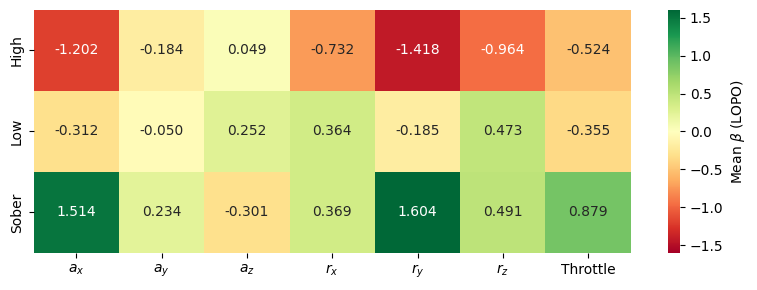

In [9]:
mean_coefs = np.array(coefs_all).mean(axis=0)

pretty = {"ax": r"$\mathit{a_x}$", "ay": r"$\mathit{a_y}$", "az": r"$\mathit{a_z}$",
           "rx": r"$\mathit{r_x}$", "ry": r"$\mathit{r_y}$", "rz": r"$\mathit{r_z}$"}
df_coefs = pd.DataFrame(mean_coefs, index=classes,
                         columns=[pretty.get(f, f.capitalize()) for f in features])

vmax = np.abs(mean_coefs).max()
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(df_coefs, annot=True, fmt=".3f", cmap="RdYlGn", center=0, vmin=-vmax, vmax=vmax,
            cbar_kws={"label": r"Mean $\beta$ (LOPO)"}, ax=ax)
fig.tight_layout()
fig.savefig("../figures/entropy_lr_coefs.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
importance = np.abs(mean_coefs).sum(axis=0)
ranking = pd.Series(importance, index=features).sort_values(ascending=False).to_frame("Sum mean |β| (LOPO)")
ranking

,Sum mean |β| (LOPO)
ry,3.207185
ax,3.027437
rz,1.927837
throttle,1.757301
rx,1.464945
az,0.602678
ay,0.468639
